## lib

In [4]:
# ==========================================
# 1. 导入所有必需的库
# ==========================================
import os
import sys
import numpy as np
from PIL import Image
from collections import namedtuple
import functools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from einops import rearrange
from tqdm import tqdm
import requests
from datetime import datetime

# ==========================================
# 2. 配置参数
# ==========================================
time_now = datetime.now().strftime("%m-%d_%H-%M")

class Config:
    DATASET_DIR = "/home/yzm"  # 修改为你的数据集根目录
    IMG_SIZE = 128                 # 图像大小 (可改为256)
    BATCH_SIZE = 2                # 批大小
    NUM_WORKERS = 4                # 数据加载线程
    MAX_EPOCHS = 50                # 训练轮数
    SAVE_DIR = f"/home/yzm/ipy/checkpoints/medvae-sd-{time_now}"  # 模型保存目录
    CUDA_NUM = 1
    
config = Config()
os.makedirs(config.SAVE_DIR, exist_ok=True)

device = torch.device(f"cuda:{config.CUDA_NUM}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:1


## MedVAE 

In [5]:
# ==========================================
# MedVAE 核心组件: Encoder & Decoder
# ==========================================

def nonlinearity(x):
    """Swish激活函数"""
    return x * torch.sigmoid(x)

def Normalize(in_channels, num_groups=32):
    return nn.GroupNorm(num_groups=num_groups, num_channels=in_channels, eps=1e-6, affine=True)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x)
        q, k, v = rearrange(qkv, "b (qkv heads c) h w -> qkv b heads c (h w)", heads=self.heads, qkv=3)
        k = k.softmax(dim=-1)
        context = torch.einsum("bhdn,bhen->bhde", k, v)
        out = torch.einsum("bhde,bhdn->bhen", context, q)
        out = rearrange(out, "b heads c (h w) -> b (heads c) h w", heads=self.heads, h=h, w=w)
        return self.to_out(out)

class LinAttnBlock(LinearAttention):
    def __init__(self, in_channels):
        super().__init__(dim=in_channels, heads=1, dim_head=in_channels)

class AttnBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.norm = Normalize(in_channels)
        self.q = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.k = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.v = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.proj_out = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def forward(self, x):
        h_ = self.norm(x)
        q, k, v = self.q(h_), self.k(h_), self.v(h_)
        b, c, h, w = q.shape
        q = q.reshape(b, c, h * w).permute(0, 2, 1)
        k = k.reshape(b, c, h * w)
        w_ = torch.bmm(q, k) * (int(c) ** (-0.5))
        w_ = F.softmax(w_, dim=2)
        v = v.reshape(b, c, h * w)
        w_ = w_.permute(0, 2, 1)
        h_ = torch.bmm(v, w_).reshape(b, c, h, w)
        return x + self.proj_out(h_)

def make_attn(in_channels, attn_type="vanilla"):
    if attn_type == "vanilla":
        return AttnBlock(in_channels)
    elif attn_type == "none":
        return nn.Identity(in_channels)
    else:
        return LinAttnBlock(in_channels)

class Upsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        if self.with_conv:
            x = self.conv(x)
        return x

class Downsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=2, padding=0)

    def forward(self, x):
        if self.with_conv:
            x = F.pad(x, (0, 1, 0, 1), mode="constant", value=0)
            x = self.conv(x)
        else:
            x = F.avg_pool2d(x, kernel_size=2, stride=2)
        return x

class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels=None, conv_shortcut=False, dropout, temb_channels=512):
        super().__init__()
        self.in_channels = in_channels
        out_channels = in_channels if out_channels is None else out_channels
        self.out_channels = out_channels
        self.use_conv_shortcut = conv_shortcut

        self.norm1 = Normalize(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        if temb_channels > 0:
            self.temb_proj = nn.Linear(temb_channels, out_channels)
        self.norm2 = Normalize(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                self.conv_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            else:
                self.nin_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x, temb):
        h = nonlinearity(self.norm1(x))
        h = self.conv1(h)
        if temb is not None:
            h = h + self.temb_proj(nonlinearity(temb))[:, :, None, None]
        h = nonlinearity(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        if self.in_channels != self.out_channels:
            x = self.conv_shortcut(x) if self.use_conv_shortcut else self.nin_shortcut(x)
        return x + h

In [6]:
# ==========================================
# Encoder 和 Decoder 类
# ==========================================

class Encoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 double_z=True, use_linear_attn=False, attn_type="vanilla", **ignore_kwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels

        # downsampling
        self.conv_in = nn.Conv2d(in_channels, self.ch, kernel_size=3, stride=1, padding=1)
        curr_res = resolution
        in_ch_mult = (1,) + tuple(ch_mult)
        self.down = nn.ModuleList()
        
        for i_level in range(self.num_resolutions):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_in = ch * in_ch_mult[i_level]
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            down = nn.Module()
            down.block = block
            down.attn = attn
            if i_level != self.num_resolutions - 1:
                down.downsample = Downsample(block_in, resamp_with_conv)
                curr_res = curr_res // 2
            self.down.append(down)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, 2 * z_channels if double_z else z_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        temb = None
        hs = [self.conv_in(x)]
        for i_level in range(self.num_resolutions):
            for i_block in range(self.num_res_blocks):
                h = self.down[i_level].block[i_block](hs[-1], temb)
                if len(self.down[i_level].attn) > 0:
                    h = self.down[i_level].attn[i_block](h)
                hs.append(h)
            if i_level != self.num_resolutions - 1:
                hs.append(self.down[i_level].downsample(hs[-1]))
        h = hs[-1]
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        return h


class Decoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 give_pre_end=False, tanh_out=False, use_linear_attn=False, attn_type="vanilla", **ignorekwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels
        self.give_pre_end = give_pre_end
        self.tanh_out = tanh_out

        block_in = ch * ch_mult[self.num_resolutions - 1]
        curr_res = resolution // 2 ** (self.num_resolutions - 1)

        # z to block_in
        self.conv_in = nn.Conv2d(z_channels, block_in, kernel_size=3, stride=1, padding=1)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # upsampling
        self.up = nn.ModuleList()
        for i_level in reversed(range(self.num_resolutions)):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks + 1):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            up = nn.Module()
            up.block = block
            up.attn = attn
            if i_level != 0:
                up.upsample = Upsample(block_in, resamp_with_conv)
                curr_res = curr_res * 2
            self.up.insert(0, up)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, out_ch, kernel_size=3, stride=1, padding=1)

    def forward(self, z):
        temb = None
        h = self.conv_in(z)
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        for i_level in reversed(range(self.num_resolutions)):
            for i_block in range(self.num_res_blocks + 1):
                h = self.up[i_level].block[i_block](h, temb)
                if len(self.up[i_level].attn) > 0:
                    h = self.up[i_level].attn[i_block](h)
            if i_level != 0:
                h = self.up[i_level].upsample(h)
        if self.give_pre_end:
            return h
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        if self.tanh_out:
            h = torch.tanh(h)
        return h

In [7]:
# ==========================================
# DiagonalGaussianDistribution (潜在空间分布)
# ==========================================

class DiagonalGaussianDistribution:
    def __init__(self, parameters, deterministic=False):
        self.parameters = parameters
        self.mean, self.logvar = torch.chunk(parameters, 2, dim=1)
        self.logvar = torch.clamp(self.logvar, -30.0, 20.0)
        self.deterministic = deterministic
        self.std = torch.exp(0.5 * self.logvar)
        self.var = torch.exp(self.logvar)
        if self.deterministic:
            self.var = self.std = torch.zeros_like(self.mean).to(device=self.parameters.device)

    def sample(self):
        x = self.mean + self.std * torch.randn(self.mean.shape).to(device=self.parameters.device)
        return x

    def kl(self, other=None):
        if self.deterministic:
            return torch.Tensor([0.0])
        if other is None:
            return 0.5 * torch.sum(torch.pow(self.mean, 2) + self.var - 1.0 - self.logvar, dim=[1, 2, 3])
        else:
            return 0.5 * torch.sum(
                torch.pow(self.mean - other.mean, 2) / other.var + self.var / other.var - 1.0 - self.logvar + other.logvar,
                dim=[1, 2, 3],
            )

    def nll(self, sample, dims=[1, 2, 3]):
        if self.deterministic:
            return torch.Tensor([0.0])
        logtwopi = np.log(2.0 * np.pi)
        return 0.5 * torch.sum(logtwopi + self.logvar + torch.pow(sample - self.mean, 2) / self.var, dim=dims)

    def mode(self):
        return self.mean

## data

In [5]:
# ==========================================
# ACDC 数据集 (VAE训练用，归一化到[-1,1])
# ==========================================

class ACDC_VAE_Dataset(Dataset):
    """
    ACDC数据集 - 用于VAE训练
    输出图像归一化到 [-1, 1] 范围
    """
    def __init__(self, phase='train'):
        self.root_dir = os.path.join(config.DATASET_DIR, "ACDC")
        self.target_size = config.IMG_SIZE
        
        # 找到所有 .npy 文件
        file_paths = []
        if os.path.exists(self.root_dir):
            group_path = [entry for entry in os.scandir(self.root_dir) if entry.is_dir()]
            for gp in group_path:
                for frame_path in os.scandir(gp):
                    if frame_path.name not in ['ED', 'ES']: 
                        continue
                    p_path = os.path.join(frame_path.path, f'{phase}_image', 'slices')
                    if not os.path.exists(p_path): 
                        continue
                    for img_file in os.scandir(p_path):
                        if img_file.name.endswith('.npy'):
                            file_paths.append(img_file.path)
        file_paths.sort()

        # 预扫描：统计每个npy里的切片数并展平
        self.all_slices = []
        for f_path in file_paths:
            vol = np.load(f_path)
            num_slices = vol.shape[0] if vol.ndim == 3 else 1
            for s_idx in range(num_slices):
                self.all_slices.append((f_path, s_idx))
        
        print(f"[{phase}] 数据集大小: {len(self.all_slices)} 个切片")

    def __len__(self): 
        return len(self.all_slices)

    def __getitem__(self, idx):
        img_path, slice_idx = self.all_slices[idx]
        
        # 加载数据
        image_vol = np.load(img_path)
        image = image_vol[slice_idx] if image_vol.ndim == 3 else image_vol

        # 归一化到 [0, 1]
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        
        # 转为PIL并裁剪
        img_pil = Image.fromarray((image * 255).astype(np.uint8))
        img_pil = TF.center_crop(img_pil, [self.target_size, self.target_size])
        
        # 转tensor并归一化到 [-1, 1] (VAE要求)
        img_tensor = TF.to_tensor(img_pil)  # [0, 1]
        img_tensor = img_tensor * 2.0 - 1.0  # [-1, 1]
        
        return img_tensor

## vae class

In [8]:
# ==========================================
# AutoencoderKL 模型 (medvae_4_1_2d 配置)
# ==========================================

class AutoencoderKL(nn.Module):
    """
    2D VAE 模型 - medvae_4_1_2d 配置
    - 4x 空间压缩
    - 1 通道输入 (灰度图)
    - 4 通道潜在空间
    """
    def __init__(self, ddconfig, embed_dim, ckpt_path=None, ignore_keys=[], apply_channel_ds=False):
        super().__init__()
        # Encoder和Decoder
        self.encoder = Encoder(**ddconfig)
        self.decoder = Decoder(**ddconfig)
        
        # 量化卷积层
        assert ddconfig["double_z"]
        self.quant_conv = nn.Conv2d(2 * ddconfig["z_channels"], 2 * embed_dim, 1)
        self.post_quant_conv = nn.Conv2d(embed_dim, ddconfig["z_channels"], 1)
        self.embed_dim = embed_dim

        # Stage 2 的通道下采样 (第一阶段不需要)
        self.apply_channel_ds = apply_channel_ds
        if self.apply_channel_ds:
            self.channel_ds = nn.Sequential(
                nn.Conv2d(self.embed_dim, 64, 1),
                nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding="same"),
                nn.ReLU(),
                nn.Conv2d(64, self.embed_dim, 1),
            )
            self.channel_proj = nn.Conv2d(self.embed_dim, self.embed_dim, 1)

        if ckpt_path is not None:
            self.init_from_ckpt(ckpt_path, ignore_keys=ignore_keys)

    def init_from_ckpt(self, path, ignore_keys=[]):
        sd = torch.load(path, map_location="cpu")
        if "state_dict" in sd:
            sd = sd["state_dict"]
        keys = list(sd.keys())
        for k in keys:
            for ik in ignore_keys:
                if k.startswith(ik):
                    print(f"Deleting key {k} from state_dict.")
                    del sd[k]
        self.load_state_dict(sd, strict=False)
        print(f"Restored from {path}")

    def encode(self, x):
        """编码: 图像 -> 潜在分布"""
        h = self.encoder(x)
        moments = self.quant_conv(h)
        posterior = DiagonalGaussianDistribution(moments)
        return posterior

    def decode(self, z):
        """解码: 潜在向量 -> 图像"""
        z = self.post_quant_conv(z)
        dec = self.decoder(z)
        return dec

    def forward(self, input, sample_posterior=True):
        """前向传播"""
        posterior = self.encode(input)
        if sample_posterior:
            z = posterior.sample()
        else:
            z = posterior.mode()
        
        if self.apply_channel_ds:
            z = self.channel_proj(self.channel_ds(z) + z)
        
        dec = self.decode(z)
        return dec, posterior, z

    def get_last_layer(self):
        """获取decoder最后一层权重 (用于自适应权重计算)"""
        return self.decoder.conv_out.weight


# medvae_4_1_2d 配置
ddconfig = {
    "double_z": True,           # 使用双倍z通道
    "z_channels": 4,            # 潜在空间通道数
    "resolution": config.IMG_SIZE,  # 输入分辨率
    "in_channels": 1,           # 输入通道 (灰度)
    "out_ch": 1,                # 输出通道
    "ch": 128,                  # 基础特征通道数
    "ch_mult": [1, 2, 4, 4],    # 4x压缩: 128->64->32->32
    "num_res_blocks": 2,        # 每层残差块数量
    "attn_resolutions": [32],   # 使用注意力的分辨率
    "dropout": 0.0
}
embed_dim = 4  # 潜在通道数

print(f"模型配置: medvae_4_1_2d")
print(f"  输入分辨率: {ddconfig['resolution']}x{ddconfig['resolution']}")
print(f"  输入通道: {ddconfig['in_channels']}")
print(f"  潜在空间: {embed_dim} 通道, {ddconfig['resolution']//4}x{ddconfig['resolution']//4} 分辨率")
print(f"  压缩比: 4x 空间压缩")

模型配置: medvae_4_1_2d
  输入分辨率: 128x128
  输入通道: 1
  潜在空间: 4 通道, 32x32 分辨率
  压缩比: 4x 空间压缩


## loss

In [9]:
# ==========================================
# LPIPS 感知损失 + 判别器
# ==========================================

def hinge_loss(logits_real, logits_fake):
    """Hinge loss for discriminator"""
    loss_real = torch.mean(F.relu(1.0 - logits_real))
    loss_fake = torch.mean(F.relu(1.0 + logits_fake))
    return 0.5 * (loss_real + loss_fake)

class ScalingLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("shift", torch.Tensor([-0.030, -0.088, -0.188])[None, :, None, None])
        self.register_buffer("scale", torch.Tensor([0.458, 0.448, 0.450])[None, :, None, None])

    def forward(self, inp):
        return (inp - self.shift) / self.scale

class NetLinLayer(nn.Module):
    def __init__(self, chn_in, chn_out=1, use_dropout=False):
        super().__init__()
        layers = [nn.Dropout()] if use_dropout else []
        layers += [nn.Conv2d(chn_in, chn_out, 1, stride=1, padding=0, bias=False)]
        self.model = nn.Sequential(*layers)

class vgg16(nn.Module):
    def __init__(self, requires_grad=False):
        super().__init__()
        vgg_pretrained_features = models.vgg16(weights="VGG16_Weights.IMAGENET1K_V1").features
        self.slice1 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(4)])
        self.slice2 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(4, 9)])
        self.slice3 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(9, 16)])
        self.slice4 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(16, 23)])
        self.slice5 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(23, 30)])
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        h = self.slice1(X)
        h_relu1_2 = h
        h = self.slice2(h)
        h_relu2_2 = h
        h = self.slice3(h)
        h_relu3_3 = h
        h = self.slice4(h)
        h_relu4_3 = h
        h = self.slice5(h)
        h_relu5_3 = h
        return namedtuple("VggOutputs", ["relu1_2", "relu2_2", "relu3_3", "relu4_3", "relu5_3"])(
            h_relu1_2, h_relu2_2, h_relu3_3, h_relu4_3, h_relu5_3
        )

def normalize_tensor(x, eps=1e-10):
    return x / (torch.sqrt(torch.sum(x**2, dim=1, keepdim=True)) + eps)

def spatial_average(x, keepdim=True):
    return x.mean([2, 3], keepdim=keepdim)

def get_ckpt_path(name, root, check=False):
    """下载VGG LPIPS权重"""
    vgg_url = "https://heibox.uni-heidelberg.de/f/607503859c864bc1b30b/?dl=1"
    path = os.path.join(root, "vgg.pth")
    if not os.path.exists(path):
        print(f"Downloading {name} model from {vgg_url} to {path}")
        os.makedirs(root, exist_ok=True)
        with requests.get(vgg_url, stream=True) as r:
            total_size = int(r.headers.get("content-length", 0))
            with tqdm(total=total_size, unit="B", unit_scale=True) as pbar:
                with open(path, "wb") as f:
                    for data in r.iter_content(chunk_size=1024):
                        if data:
                            f.write(data)
                            pbar.update(len(data))
    return path

class LPIPS(nn.Module):
    """LPIPS感知损失"""
    def __init__(self, use_dropout=True):
        super().__init__()
        self.scaling_layer = ScalingLayer()
        self.chns = [64, 128, 256, 512, 512]
        self.net = vgg16(requires_grad=False)
        self.lin0 = NetLinLayer(self.chns[0], use_dropout=use_dropout)
        self.lin1 = NetLinLayer(self.chns[1], use_dropout=use_dropout)
        self.lin2 = NetLinLayer(self.chns[2], use_dropout=use_dropout)
        self.lin3 = NetLinLayer(self.chns[3], use_dropout=use_dropout)
        self.lin4 = NetLinLayer(self.chns[4], use_dropout=use_dropout)
        self.load_from_pretrained()
        for param in self.parameters():
            param.requires_grad = False

    def load_from_pretrained(self, name="vgg_lpips"):
        ckpt = get_ckpt_path(name, ".cache")
        self.load_state_dict(torch.load(ckpt, map_location="cpu"), strict=False)
        print(f"Loaded pretrained LPIPS from {ckpt}")

    def forward(self, input, target):
        # LPIPS需要3通道输入，单通道需要复制
        if input.shape[1] == 1:
            input = input.repeat(1, 3, 1, 1)
            target = target.repeat(1, 3, 1, 1)
        
        in0_input, in1_input = self.scaling_layer(input), self.scaling_layer(target)
        outs0, outs1 = self.net(in0_input), self.net(in1_input)
        
        lins = [self.lin0, self.lin1, self.lin2, self.lin3, self.lin4]
        val = 0
        for kk in range(len(self.chns)):
            feats0, feats1 = normalize_tensor(outs0[kk]), normalize_tensor(outs1[kk])
            diffs = (feats0 - feats1) ** 2
            val += spatial_average(lins[kk].model(diffs), keepdim=True)
        return val


class NLayerDiscriminator(nn.Module):
    """PatchGAN判别器"""
    def __init__(self, input_nc=3, ndf=64, n_layers=3, use_actnorm=False):
        super().__init__()
        norm_layer = nn.BatchNorm2d
        kw, padw = 4, 1
        sequence = [nn.Conv2d(input_nc, ndf, kernel_size=kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        
        nf_mult = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=False),
                norm_layer(ndf * nf_mult),
                nn.LeakyReLU(0.2, True),
            ]
        
        nf_mult_prev = nf_mult
        nf_mult = min(2**n_layers, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=False),
            norm_layer(ndf * nf_mult),
            nn.LeakyReLU(0.2, True),
        ]
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]
        self.main = nn.Sequential(*sequence)

    def forward(self, input):
        return self.main(input)

In [10]:
# ==========================================
# Score Divergence 损失函数
# ==========================================

def score_fn_2d(z: torch.Tensor, x_target: torch.Tensor, decoder, sigma2=1.0) -> torch.Tensor:
    """
    计算 ∇_z log p(z, x_target) 用于2D图像VAE
    
    参数：
        z: [B, C, H, W]，需要设置 requires_grad=True
        x_target: [B, C_img, H_img, W_img]，原始图像
        decoder: VAE的decoder (包含post_quant_conv)
        sigma2: 高斯观测模型的方差
    返回：
        score: [B, C, H, W]，对应每个 z 的梯度
    """
    assert z.requires_grad, "z must have requires_grad=True"
    
    B = z.shape[0]
    
    # 解码重建
    x_rec = decoder(z)  # [B, C_img, H_img, W_img]
    
    # log p(z) = -0.5 * ||z||^2 (标准正态先验)
    # 对于2D潜在空间，在所有维度上求和
    # grad_pz = -z  # [B, C, H, W]
    
    # log p(x|z) = -1/(2σ²) * ||x - decoder(z)||²
    diff = x_target - x_rec
    logpx = -0.5 / sigma2 * (diff ** 2).sum(dim=[1, 2,  3])  # [B]
    
    # 对 z 求梯度
    grad_px = torch.autograd.grad(logpx.sum(), z, create_graph=True, retain_graph=True)[0]
    
    # 合并: g(z) = ∇ log p(z) + ∇ log p(x|z)
    g = -z + grad_px  # [B, C, H, W]
    
    return g


def score_divergence_loss(mu, logvar, x_target, decoder, sample_K=2, sigma2=1.0):
    """
    Score Divergence 损失 (Dq) - 适配2D VAE
    
    参数：
        mu: [N, C, H, W] - 潜在空间均值
        logvar: [N, C, H, W] - 潜在空间log方差
        x_target: [N, C_img, H_img, W_img] - 原始图像
        decoder: VAE decoder
        sample_K: 每个样本采样K个z
        sigma2: 观测噪声方差
    返回：
        标量 loss
    """
    N, C, H, W = mu.shape
    D = C * H * W  # 潜在空间总维度
    
    # 重参数化采样 z: [N, K, C, H, W]
    std = torch.exp(0.5 * logvar)
    var = std ** 2
    eps = torch.randn(N, sample_K, C, H, W, device=mu.device)
    z = mu.unsqueeze(1) + eps * std.unsqueeze(1)  # [N, K, C, H, W]
    
    # 展平为 [N*K, C, H, W] 用于批量计算
    z_flat = z.view(N * sample_K, C, H, W)
    z_flat.requires_grad_(True)
    
    # 扩展 x_target: [N, ...] -> [N*K, ...]
    x_rep = x_target.unsqueeze(1).expand(N, sample_K, *x_target.shape[1:])
    x_rep = x_rep.reshape(N * sample_K, *x_target.shape[1:])
    
    # 计算 score
    scores_flat = score_fn_2d(z_flat, x_rep, decoder, sigma2)  # [N*K, C, H, W]
    scores = scores_flat.view(N, sample_K, C, H, W)  # [N, K, C, H, W]
    
    # Score-matching 损失计算
    # term2: E[g^T Σ g] = E[sum_d var_d * g_d^2]
    var_expanded = var.unsqueeze(1)  # [N, 1, C, H, W]
    g_norm2_sigma = (var_expanded * scores ** 2).sum(dim=[2, 3, 4])  # [N, K]
    
    # term3: 2 * E[(z - mu)^T g]
    mu_expanded = mu.unsqueeze(1)  # [N, 1, C, H, W]
    align_term = ((z - mu_expanded) * scores).sum(dim=[2, 3, 4])  # [N, K]
    
    # Score Divergence = term2 + 2*term3 (省略常数项 tr(I)=D)
    term2 = g_norm2_sigma.mean(dim=1)  # [N]
    term3 = 2 * align_term.mean(dim=1)  # [N]
    
    score_div = term2 + term3  # [N]
    
    return score_div.mean()


def compute_kl_t(mu, logvar, mu_old, logvar_old):
    """
    计算当前分布与上一次迭代分布之间的 KL 散度
    KL(q_new || q_old)
    
    参数：
        mu, logvar: 当前分布参数 [N, C, H, W]
        mu_old, logvar_old: 上一次迭代的分布参数 [N, C, H, W]
    返回：
        KL_t: 标量
    """
    var = torch.exp(logvar)
    var_old = torch.exp(logvar_old)
    
    # KL(q_new || q_old) 在所有维度上求和
    kl_per_sample = 0.5 * (
        torch.log(var_old / var) +
        (var + (mu - mu_old).pow(2)) / var_old - 1
    ).sum(dim=[1, 2, 3])  # [N]
    
    return kl_per_sample.mean()

In [11]:
# ==========================================
# VAE损失函数: LPIPS + Discriminator + Score Divergence
# ==========================================

class LPIPSWithDiscriminator(nn.Module):
    """
    VAE完整损失函数 (带Score Divergence)
    包含: L1重建损失 + LPIPS感知损失 + Score Divergence(Dq) + KL_t + GAN判别器损失
    
    替换原来的KL散度为: dq_weight * Dq + klt_weight * KL_t
    其中:
        - Dq: Score Divergence, 衡量变分分布与真实后验之间的差异
        - KL_t: 当前分布与上一次迭代分布之间的KL散度
    """
    def __init__(self, disc_start=3125, kl_weight=1.0e-06, dq_weight=0.5, klt_weight=0.02, pixelloss_weight=1.0,
                 perceptual_weight=1.0, disc_weight=0.5, disc_in_channels=1, 
                 sample_K=2, sigma2=1.0):
        super().__init__()
        # Score Divergence 参数
        self.kl_weight = kl_weight
        self.dq_weight = dq_weight      # Score Divergence 权重
        self.klt_weight = klt_weight    # KL_t 权重
        self.sample_K = sample_K        # 每个样本采样的z数量
        self.sigma2 = sigma2            # 观测噪声方差
        
        self.pixel_weight = pixelloss_weight
        self.perceptual_weight = perceptual_weight
        self.disc_weight = disc_weight
        
        # LPIPS感知损失
        self.perceptual_loss = LPIPS().eval()
        
        # PatchGAN判别器
        self.discriminator = NLayerDiscriminator(input_nc=disc_in_channels, n_layers=3)
        self.discriminator_iter_start = disc_start

    def calculate_adaptive_weight(self, nll_loss, g_loss, last_layer):
        """自适应权重: 平衡重建损失和GAN损失"""
        nll_grads = torch.autograd.grad(nll_loss, last_layer, retain_graph=True)[0]
        g_grads = torch.autograd.grad(g_loss, last_layer, retain_graph=True)[0]
        d_weight = torch.norm(nll_grads) / (torch.norm(g_grads) + 1e-4)
        d_weight = torch.clamp(d_weight, 0.0, 1e4).detach()
        return d_weight * self.disc_weight

    def forward(self, inputs, reconstructions, posteriors, optimizer_idx, global_step, 
                last_layer=None, decoder=None, mu_old=None, logvar_old=None):
        """
        参数:
            inputs: 原始图像 [B, C, H, W]
            reconstructions: 重建图像 [B, C, H, W]
            posteriors: DiagonalGaussianDistribution 对象
            optimizer_idx: 0=autoencoder, 1=discriminator
            global_step: 全局训练步数
            last_layer: decoder最后一层参数 (用于自适应权重)
            decoder: VAE的decoder函数 (用于Score Divergence)
            mu_old, logvar_old: 上一次迭代的分布参数 (用于KL_t)
        """
        # L1重建损失
        rec_loss = torch.abs(inputs.contiguous() - reconstructions.contiguous())
        
        # LPIPS感知损失
        p_loss = self.perceptual_loss(inputs.contiguous(), reconstructions.contiguous())
        rec_loss = rec_loss + self.perceptual_weight * p_loss
        
        nll_loss = rec_loss.mean()
        
        # 获取当前分布参数
        mu = posteriors.mean
        logvar = posteriors.logvar

        # ========== Autoencoder损失 ==========
        if optimizer_idx == 0:
            # ========== Score Divergence (Dq) ==========
            if decoder is not None:
                dq_loss = score_divergence_loss(
                    mu, logvar, inputs, decoder, 
                    sample_K=self.sample_K, sigma2=self.sigma2
                )
            else:
                # 如果没有提供decoder，回退到KL散度
                dq_loss = posteriors.kl().mean()
            
            # ========== KL_t (与上一次迭代的KL散度) ==========
            if mu_old is not None and logvar_old is not None:
                kl_t_loss = compute_kl_t(mu, logvar, mu_old, logvar_old)
            else:
                # 第一次迭代或者没有提供旧参数时，使用标准先验KL
                kl_t_loss = posteriors.kl().mean()
            
            # ========== GAN损失 ==========
            if global_step >= self.discriminator_iter_start:
                logits_fake = self.discriminator(reconstructions.contiguous())
                g_loss = -torch.mean(logits_fake)
                
                # 自适应权重
                try:
                    d_weight = self.calculate_adaptive_weight(nll_loss, g_loss, last_layer)
                except RuntimeError:
                    d_weight = torch.tensor(self.disc_weight)
            else:
                g_loss = torch.tensor(0.0, device=inputs.device)
                d_weight = torch.tensor(0.0, device=inputs.device)
            
            # 总损失: L_rec + dq_weight*Dq + klt_weight*KL_t + d_weight*g_loss
            loss = nll_loss + self.kl_weight*(self.dq_weight * dq_loss + self.klt_weight * kl_t_loss) + d_weight * g_loss
            
            log = {
                "total_loss": loss.item(),
                "rec_loss": nll_loss.item(),
                "dq_loss": dq_loss.item(),
                "kl_t_loss": kl_t_loss.item(),
                "g_loss": g_loss.item() if isinstance(g_loss, torch.Tensor) else g_loss,
                "d_weight": d_weight.item() if isinstance(d_weight, torch.Tensor) else d_weight,
            }
            return loss, log

        # ========== 判别器损失 ==========
        elif optimizer_idx == 1:
            logits_real = self.discriminator(inputs.contiguous().detach())
            logits_fake = self.discriminator(reconstructions.contiguous().detach())
            d_loss = hinge_loss(logits_real, logits_fake)
            
            log = {
                "disc_loss": d_loss.item(),
                "logits_real": logits_real.mean().item(),
                "logits_fake": logits_fake.mean().item(),
            }
            return self.disc_weight * d_loss, log

## run

In [23]:
# ==========================================
# 初始化模型、损失、优化器
# ==========================================

# 创建模型
model = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
print(f"模型参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

# 创建损失函数 (使用 Score Divergence)
criterion = LPIPSWithDiscriminator(
    disc_start=3125,          # 判别器延迟启动 (约100个epoch后)
    kl_weight=1e-5,
    dq_weight=1,            # Score Divergence (Dq) 权重
    klt_weight=1e-10,          # KL_t 权重 (当前分布与上一次迭代的KL)
    pixelloss_weight=1.0,     # L1损失权重
    perceptual_weight=1.0,    # LPIPS权重
    disc_weight=0.5,          # 判别器权重
    disc_in_channels=1,       # 单通道输入
    sample_K=2,               # Score Divergence 采样数
    sigma2=1.0                # 观测噪声方差
).to(device)

# 优化器
batch_size = config.BATCH_SIZE
base_learning_rate = 4.5e-6
lr = batch_size * base_learning_rate

optimizer_ae = torch.optim.Adam(
    list(model.encoder.parameters()) +
    list(model.decoder.parameters()) +
    list(model.quant_conv.parameters()) +
    list(model.post_quant_conv.parameters()),
    lr=lr,
    betas=(0.5, 0.9)
)

optimizer_disc = torch.optim.Adam(
    criterion.discriminator.parameters(),
    lr=lr,
    betas=(0.5, 0.9)
)

print(f"学习率: {lr:.2e}")
print(f"判别器启动步数: {criterion.discriminator_iter_start}")

模型参数量: 88.91M
Loaded pretrained LPIPS from .cache/vgg.pth
学习率: 9.00e-06
判别器启动步数: 3125


In [24]:
# ==========================================
# 创建数据加载器
# ==========================================

train_dataset = ACDC_VAE_Dataset(phase='train')
val_dataset = ACDC_VAE_Dataset(phase='val')

train_loader = DataLoader(
    train_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=True, 
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=False, 
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"每epoch训练步数: {len(train_loader)}")

[train] 数据集大小: 1276 个切片
[val] 数据集大小: 282 个切片
训练集大小: 1276
验证集大小: 282
每epoch训练步数: 638


In [25]:
# ==========================================
# 训练循环 (支持 Score Divergence + KL_t)
# ==========================================

def create_decoder_fn(model):
    """创建一个用于Score Divergence的decoder函数"""
    def decoder_fn(z):
        z = model.post_quant_conv(z)
        dec = model.decoder(z)
        return dec
    return decoder_fn


def train_one_epoch(model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step):
    model.train()
    criterion.discriminator.train()
    
    total_ae_loss = 0
    total_disc_loss = 0
    total_dq_loss = 0
    total_klt_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    # 创建decoder函数用于Score Divergence
    decoder_fn = create_decoder_fn(model)
    
    # 保存上一次迭代的分布参数 (用于KL_t)
    mu_old = None
    logvar_old = None
    
    for batch_idx, images in enumerate(pbar):
        images = images.to(device)
        
        # 前向传播
        reconstructions, posterior, z = model(images)
        
        # ========== 训练Autoencoder (带Score Divergence) ==========
        ae_loss, ae_log = criterion(
            inputs=images,
            reconstructions=reconstructions,
            posteriors=posterior,
            optimizer_idx=0,
            global_step=global_step,
            last_layer=model.get_last_layer(),
            decoder=decoder_fn,          # 传入decoder用于Dq计算
            mu_old=mu_old,               # 上一次迭代的mu
            logvar_old=logvar_old        # 上一次迭代的logvar
        )
        
        optimizer_ae.zero_grad()
        ae_loss.backward()
        optimizer_ae.step()
        
        # 保存当前分布参数作为下一次迭代的"旧"参数
        mu_old = posterior.mean.detach().clone()
        logvar_old = posterior.logvar.detach().clone()
        
        total_ae_loss += ae_log["rec_loss"]
        total_dq_loss += ae_log["dq_loss"]
        total_klt_loss += ae_log["kl_t_loss"]
        
        # ========== 训练判别器 (在disc_start之后) ==========
        disc_loss_val = 0
        if global_step >= criterion.discriminator_iter_start:
            # 重新前向传播 (用于判别器)
            with torch.no_grad():
                reconstructions, posterior, z = model(images)
            
            disc_loss, disc_log = criterion(
                inputs=images,
                reconstructions=reconstructions,
                posteriors=posterior,
                optimizer_idx=1,
                global_step=global_step
            )
            
            optimizer_disc.zero_grad()
            disc_loss.backward()
            optimizer_disc.step()
            
            disc_loss_val = disc_log["disc_loss"]
            total_disc_loss += disc_loss_val
        
        # 更新进度条
        pbar.set_postfix({
            "rec": f"{ae_log['rec_loss']:.4f}",
            "Dq": f"{ae_log['dq_loss']:.4f}",
            "KLt": f"{ae_log['kl_t_loss']:.4f}",
            "g": f"{ae_log['g_loss']:.4f}",
            "d": f"{disc_loss_val:.4f}" if disc_loss_val > 0 else "N/A"
        })
        
        global_step += 1
    
    avg_ae_loss = total_ae_loss / len(train_loader)
    avg_disc_loss = total_disc_loss / len(train_loader) if global_step > criterion.discriminator_iter_start else 0
    avg_dq_loss = total_dq_loss / len(train_loader)
    avg_klt_loss = total_klt_loss / len(train_loader)
    
    return global_step, avg_ae_loss, avg_disc_loss, avg_dq_loss, avg_klt_loss


@torch.no_grad()
def validate(model, criterion, val_loader, global_step):
    """验证函数 - 只计算重建损失，不计算Score Divergence（避免验证时的额外计算开销）"""
    model.eval()
    total_loss = 0
    
    for images in val_loader:
        images = images.to(device)
        reconstructions, posterior, z = model(images)
        
        # 验证时不需要传入decoder和mu_old/logvar_old
        # 因为我们只关心重建质量
        ae_loss, ae_log = criterion(
            inputs=images,
            reconstructions=reconstructions,
            posteriors=posterior,
            optimizer_idx=0,
            global_step=global_step,
            last_layer=model.get_last_layer(),
            decoder=None,       # 不计算Dq
            mu_old=None,        # 使用标准KL作为替代
            logvar_old=None
        )
        total_loss += ae_log["rec_loss"]
    
    return total_loss / len(val_loader)

In [28]:
# ==========================================
# 开始训练! (Score Divergence + KL_t)
# ==========================================

global_step = 0
best_val_loss = float('inf')

print("=" * 50)
print("开始训练 MedVAE (带 Score Divergence)")
print(f"损失函数: L_rec + {criterion.dq_weight}*Dq + {criterion.klt_weight}*KL_t + d_weight*g_loss")
print("=" * 50)

for epoch in range(config.MAX_EPOCHS):
    # 训练
    global_step, train_ae_loss, train_disc_loss, train_dq_loss, train_klt_loss = train_one_epoch(
        model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step
    )
    
    # 验证
    val_loss = validate(model, criterion, val_loader, global_step)
    
    print(f"\nEpoch {epoch+1}/{config.MAX_EPOCHS}")
    print(f"  Train - Rec: {train_ae_loss:.4f}, Dq: {train_dq_loss:.4f}, KL_t: {train_klt_loss:.4f}, Disc: {train_disc_loss:.4f}")
    print(f"  Val   - Rec Loss: {val_loss:.4f}")
    print(f"  Global Step: {global_step}")
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'global_step': global_step,
            'model_state_dict': model.state_dict(),
            'optimizer_ae_state_dict': optimizer_ae.state_dict(),
            'optimizer_disc_state_dict': optimizer_disc.state_dict(),
            'val_loss': val_loss,
        }, os.path.join(config.SAVE_DIR, 'medvae_sd_best.pth'))
        print(f"  ✓ 保存最佳模型 (val_loss: {val_loss:.4f})")
    
    # 定期保存检查点
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'global_step': global_step,
            'model_state_dict': model.state_dict(),
            'optimizer_ae_state_dict': optimizer_ae.state_dict(),
            'optimizer_disc_state_dict': optimizer_disc.state_dict(),
            'val_loss': val_loss,
        }, os.path.join(config.SAVE_DIR, f'medvae_sd_epoch{epoch+1}.pth'))

print("\n训练完成!")
print(f"最佳验证损失: {best_val_loss:.4f}")

In [29]:
# ==========================================
# 可视化重建结果
# ==========================================
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_reconstruction(model, dataloader, num_samples=4):
    """可视化原图和重建图的对比"""
    model.eval()
    
    # 收集足够的样本（跨多个batch）
    all_images = []
    for images in dataloader:
        all_images.append(images)
        if sum(img.shape[0] for img in all_images) >= num_samples:
            break
    
    # 拼接并截取
    images = torch.cat(all_images, dim=0)[:num_samples].to(device)
    num_samples = images.shape[0]  # 实际获取到的样本数
    
    reconstructions, _, _ = model(images)
    
    # 转换到[0,1]用于显示
    images = (images + 1) / 2
    reconstructions = (reconstructions + 1) / 2
    
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    
    # 如果只有1个样本，axes不是2D数组，需要特殊处理
    if num_samples == 1:
        axes = axes.reshape(2, 1)
    
    for i in range(num_samples):
        # 原图
        axes[0, i].imshow(images[i, 0].cpu().numpy(), cmap='gray')
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')
        
        # 重建图
        axes[1, i].imshow(reconstructions[i, 0].cpu().numpy(), cmap='gray')
        axes[1, i].set_title(f'Reconstructed {i+1}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'reconstruction_comparison.png'), dpi=150)
    plt.show()

# 可视化 (现在可以显示任意数量)
visualize_reconstruction(model, val_loader, num_samples=4)

In [30]:
# ==========================================
# 从潜在空间采样生成新图像
# ==========================================

@torch.no_grad()
def generate_samples(model, num_samples=8, latent_size=None):
    """从潜在空间随机采样生成新图像"""
    model.eval()
    
    # 计算潜在空间大小
    if latent_size is None:
        latent_size = config.IMG_SIZE // 4  # 4x压缩
    
    # 随机采样潜在向量
    z = torch.randn(num_samples, model.embed_dim, latent_size, latent_size).to(device)
    
    # 解码
    generated = model.decode(z)
    
    # 转换到[0,1]
    generated = (generated + 1) / 2
    generated = generated.clamp(0, 1)
    
    # 可视化
    fig, axes = plt.subplots(2, num_samples//2, figsize=(3*(num_samples//2), 6))
    axes = axes.flatten()
    
    for i in range(num_samples):
        axes[i].imshow(generated[i, 0].cpu().numpy(), cmap='gray')
        axes[i].set_title(f'Generated {i+1}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'generated_samples.png'), dpi=150)
    plt.show()

# 生成新样本
generate_samples(model, num_samples=8)

In [2]:
import numpy as np
data = np.load('/home/yzm/ACDC/gp1/ED/train_image/slices/gp1_ED_11_0.npy')
print(data.shape)

(256, 184)


## eof

## 数据增强：生成重构图像

In [12]:
# ==========================================
# 数据增强配置
# ==========================================

# VAE checkpoint 路径
VAE_CHECKPOINT = "/home/yzm/ipy/checkpoints/medvae-sd-01-27_23-00-47/medvae_sd_best.pth"

# ACDC2 数据集路径 (用于分割模型)
ACDC2_ROOT = "/home/yzm/ACDC2/ACDC"

# 输出尺寸 (和分割模型一致)
TARGET_SIZE = 128

In [7]:
# ==========================================
# 基于LV质心的裁剪函数 (和分割模型一致)
# ==========================================

def get_lv_centroid(label_array):
    """
    计算左心室(像素值为1)的质心坐标
    """
    lv_mask = (label_array == 1)
    
    if not np.any(lv_mask):
        # 如果没有找到左心室，返回图像中心
        h, w = label_array.shape
        return h // 2, w // 2
    
    y_coords, x_coords = np.where(lv_mask)
    center_y = round(np.mean(y_coords))
    center_x = round(np.mean(x_coords))
    return center_y, center_x


def center_crop_by_lv(image_array, label_array, target_size):
    """
    基于LV质心裁剪图像 (和分割模型的裁剪方式一致)
    
    Args:
        image_array: numpy array [H, W]
        label_array: numpy array [H, W] - 用于找LV中心
        target_size: int, 目标尺寸
    Returns:
        cropped_image: numpy array [target_size, target_size]
    """
    center_y, center_x = get_lv_centroid(label_array)
    
    H, W = image_array.shape
    half = target_size // 2
    
    # 计算裁剪窗口
    y0 = center_y - half
    x0 = center_x - half
    y1 = y0 + target_size
    x1 = x0 + target_size
    
    # 计算填充量
    pad_top = max(0, -y0)
    pad_left = max(0, -x0)
    pad_bottom = max(0, y1 - H)
    pad_right = max(0, x1 - W)
    
    if pad_top or pad_left or pad_bottom or pad_right:
        # 使用反射填充
        try:
            image_array = np.pad(image_array,
                                ((pad_top, pad_bottom), (pad_left, pad_right)),
                                mode='reflect')
        except:
            image_array = np.pad(image_array,
                                ((pad_top, pad_bottom), (pad_left, pad_right)),
                                mode='edge')
        
        center_y += pad_top
        center_x += pad_left
    
    # 裁剪
    start_y = center_y - half
    start_x = center_x - half
    cropped = image_array[start_y:start_y+target_size, start_x:start_x+target_size]
    
    return cropped

In [14]:
# ==========================================
# 加载训练好的VAE模型
# ==========================================

# 重新创建模型 (使用相同配置)
vae_model = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)

# 加载checkpoint
checkpoint = torch.load(VAE_CHECKPOINT, map_location=device)
if 'model_state_dict' in checkpoint:
    vae_model.load_state_dict(checkpoint['model_state_dict'])
else:
    vae_model.load_state_dict(checkpoint)

vae_model.eval()
print(f"✓ 已加载VAE模型: {VAE_CHECKPOINT}")
print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}, Val Loss: {checkpoint.get('val_loss', 'N/A')}")

✓ 已加载VAE模型: /home/yzm/ipy/checkpoints/medvae-sd-01-27_23-00-47/medvae_sd_best.pth
  Epoch: 43, Val Loss: 0.2861947846328113


In [15]:
# ==========================================
# 收集ACDC2所有训练集图像和对应标签路径
# ==========================================

def collect_acdc2_train_files(root_dir):
    """
    收集ACDC2训练集的所有图像和标签文件路径
    返回: [(image_path, label_path, output_dir), ...]
    """
    pairs = []
    
    for gp in os.scandir(root_dir):
        if not gp.is_dir():
            continue
        for frame in os.scandir(gp.path):
            if frame.name not in ['ED', 'ES']:
                continue
            
            img_dir = os.path.join(frame.path, 'train_image', 'slices')
            label_dir = os.path.join(frame.path, 'train_label', 'slices')
            aug_dir = os.path.join(frame.path, 'train_image_aug', 'slices')  # 输出目录
            
            if not os.path.exists(img_dir) or not os.path.exists(label_dir):
                continue
            
            for img_file in os.scandir(img_dir):
                if not img_file.name.endswith('.npy'):
                    continue
                
                label_path = os.path.join(label_dir, img_file.name)
                if os.path.exists(label_path):
                    pairs.append((img_file.path, label_path, aug_dir))
    
    pairs.sort(key=lambda x: x[0])
    return pairs


# 收集文件
train_pairs = collect_acdc2_train_files(ACDC2_ROOT)
print(f"找到 {len(train_pairs)} 个训练图像-标签对")

# 显示示例
if len(train_pairs) > 0:
    print(f"\n示例:")
    print(f"  图像: {train_pairs[0][0]}")
    print(f"  标签: {train_pairs[0][1]}")
    print(f"  输出: {train_pairs[0][2]}")

找到 638 个训练图像-标签对

示例:
  图像: /home/yzm/ACDC2/ACDC/gp1/ED/train_image/slices/gp1_ED_11_0.npy
  标签: /home/yzm/ACDC2/ACDC/gp1/ED/train_label/slices/gp1_ED_11_0.npy
  输出: /home/yzm/ACDC2/ACDC/gp1/ED/train_image_aug/slices


In [16]:
# ==========================================
# 生成重构图像并保存
# ==========================================

@torch.no_grad()
def generate_augmented_images(vae_model, train_pairs, target_size=128, batch_size=16):
    """
    使用VAE生成重构图像作为数据增强
    
    Args:
        vae_model: 训练好的VAE模型
        train_pairs: [(image_path, label_path, output_dir), ...]
        target_size: 裁剪后的图像尺寸
        batch_size: 批处理大小
    """
    vae_model.eval()
    
    total_generated = 0
    skipped = 0
    
    # 按输出目录分组处理
    from collections import defaultdict
    by_output_dir = defaultdict(list)
    for img_path, label_path, out_dir in train_pairs:
        by_output_dir[out_dir].append((img_path, label_path))
    
    for out_dir, pairs in tqdm(by_output_dir.items(), desc="处理目录"):
        # 创建输出目录
        os.makedirs(out_dir, exist_ok=True)
        
        for img_path, label_path in pairs:
            filename = os.path.basename(img_path)
            out_path = os.path.join(out_dir, filename.replace('.npy', '_aug.npy'))
            
            # 跳过已存在的文件
            if os.path.exists(out_path):
                skipped += 1
                continue
            
            try:
                # 加载图像和标签
                image = np.load(img_path)
                label = np.load(label_path)
                
                # 归一化到[0,1]
                image = (image - image.min()) / (image.max() - image.min() + 1e-8)
                
                # 基于LV质心裁剪 (和分割模型一致!)
                cropped = center_crop_by_lv(image, label, target_size)
                
                # 转为tensor, 归一化到[-1, 1]
                img_tensor = torch.from_numpy(cropped).float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
                img_tensor = img_tensor * 2.0 - 1.0  # [-1, 1]
                img_tensor = img_tensor.to(device)
                
                # VAE重构
                reconstructed, _, _ = vae_model(img_tensor, sample_posterior=True)
                
                # 转回numpy, 范围[0, 1]
                rec_np = (reconstructed.squeeze().cpu().numpy() + 1.0) / 2.0
                rec_np = np.clip(rec_np, 0, 1)
                
                # 保存为npy (保持float32)
                np.save(out_path, rec_np.astype(np.float32))
                total_generated += 1
                
            except Exception as e:
                print(f"  错误处理 {img_path}: {e}")
                continue
    
    print(f"\n✓ 完成!")
    print(f"  生成: {total_generated} 张重构图像")
    print(f"  跳过: {skipped} 张已存在的图像")
    
    return total_generated


# 开始生成!
print("=" * 50)
print("开始生成数据增强图像...")
print(f"  VAE模型: {VAE_CHECKPOINT}")
print(f"  输出尺寸: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"  裁剪方式: 基于LV质心 (和分割模型一致)")
print("=" * 50)

num_generated = generate_augmented_images(vae_model, train_pairs, target_size=TARGET_SIZE)

开始生成数据增强图像...
  VAE模型: /home/yzm/ipy/checkpoints/medvae-sd-01-27_23-00-47/medvae_sd_best.pth
  输出尺寸: 128x128
  裁剪方式: 基于LV质心 (和分割模型一致)


处理目录: 100%|██████████| 10/10 [00:11<00:00,  1.14s/it]


✓ 完成!
  生成: 638 张重构图像
  跳过: 0 张已存在的图像


/tmp/ipykernel_650833/4098324828.py:50: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_650833/4098324828.py:50: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_650833/4098324828.py:50: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_650833/4098324828.py:50: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_650833/4098324828.py:50: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_650833/4098324828.py:50: UserWarning: Glyph 24322 (\N{CJK UNIFIED IDEOGRAPH-5F02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_650833/4098324828.py:51: UserWarning: Glyph 21407 (\N{CJK UNIFIED I

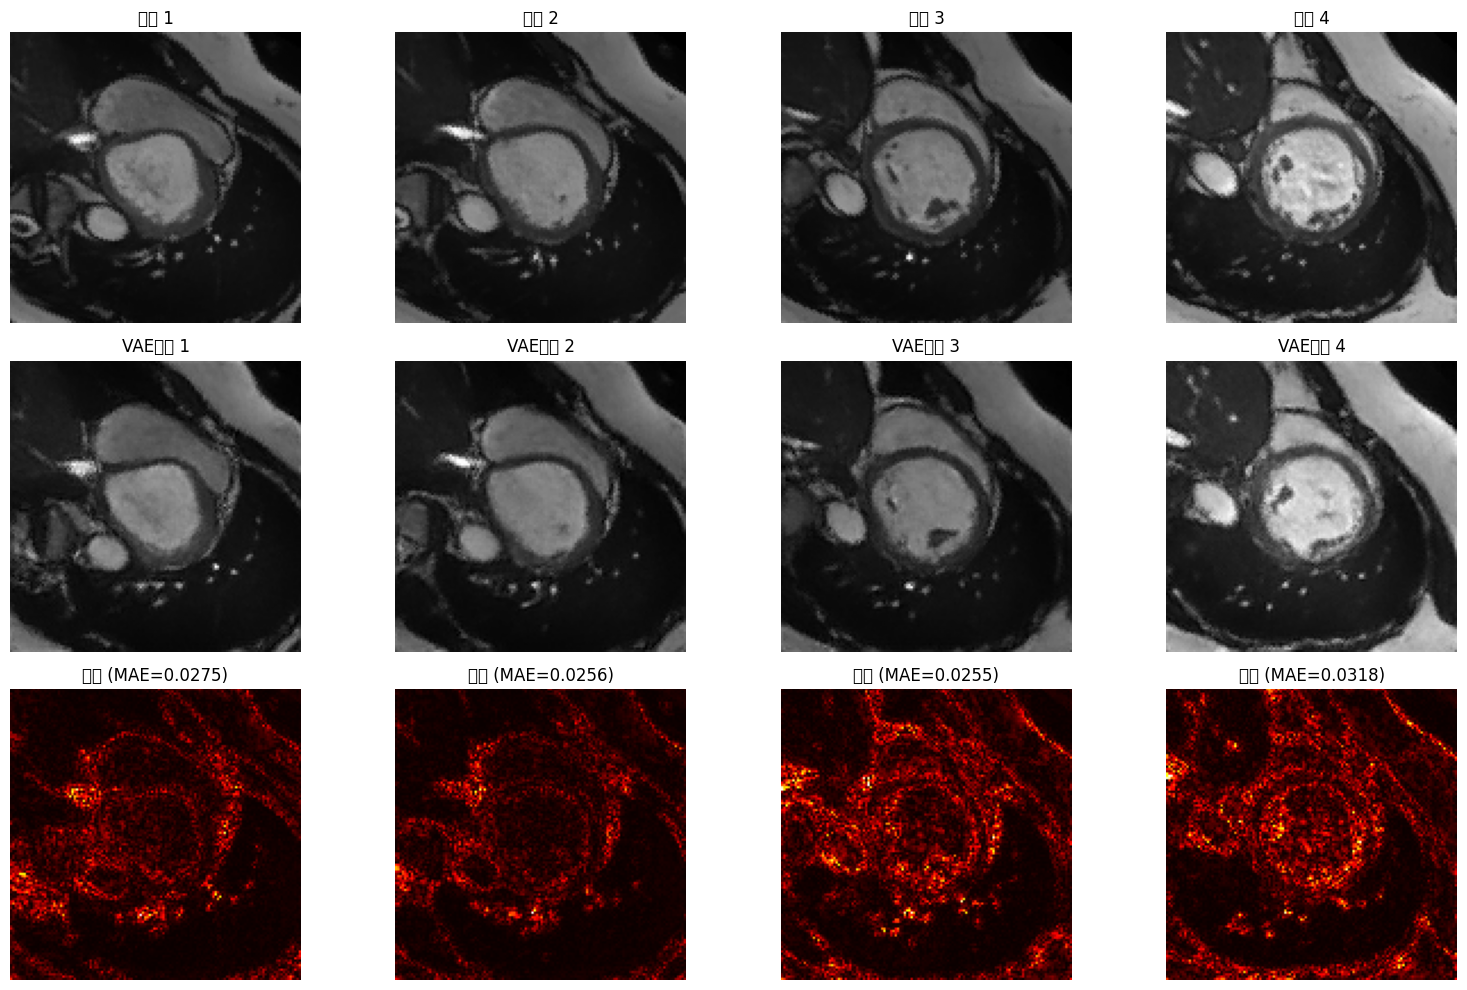

In [17]:
# ==========================================
# 可视化对比: 原图 vs 重构图
# ==========================================

def visualize_augmentation_samples(train_pairs, num_samples=4):
    """可视化原图和增强图的对比"""
    import matplotlib.pyplot as plt
    
    samples = []
    for img_path, label_path, out_dir in train_pairs[:50]:  # 从前50个中找
        filename = os.path.basename(img_path)
        aug_path = os.path.join(out_dir, filename.replace('.npy', '_aug.npy'))
        if os.path.exists(aug_path):
            samples.append((img_path, label_path, aug_path))
        if len(samples) >= num_samples:
            break
    
    if len(samples) == 0:
        print("没有找到生成的增强图像!")
        return
    
    fig, axes = plt.subplots(3, len(samples), figsize=(4*len(samples), 10))
    
    for i, (img_path, label_path, aug_path) in enumerate(samples):
        # 加载数据
        image = np.load(img_path)
        label = np.load(label_path)
        aug = np.load(aug_path)
        
        # 归一化原图并裁剪
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        cropped_orig = center_crop_by_lv(image, label, TARGET_SIZE)
        
        # 原图
        axes[0, i].imshow(cropped_orig, cmap='gray')
        axes[0, i].set_title(f'原图 {i+1}')
        axes[0, i].axis('off')
        
        # 重构图
        axes[1, i].imshow(aug, cmap='gray')
        axes[1, i].set_title(f'VAE重构 {i+1}')
        axes[1, i].axis('off')
        
        # 差异图
        diff = np.abs(cropped_orig - aug)
        axes[2, i].imshow(diff, cmap='hot')
        axes[2, i].set_title(f'差异 (MAE={diff.mean():.4f})')
        axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'augmentation_comparison.png'), dpi=150)
    plt.show()

# 可视化
visualize_augmentation_samples(train_pairs, num_samples=4)

找到 10 个类别


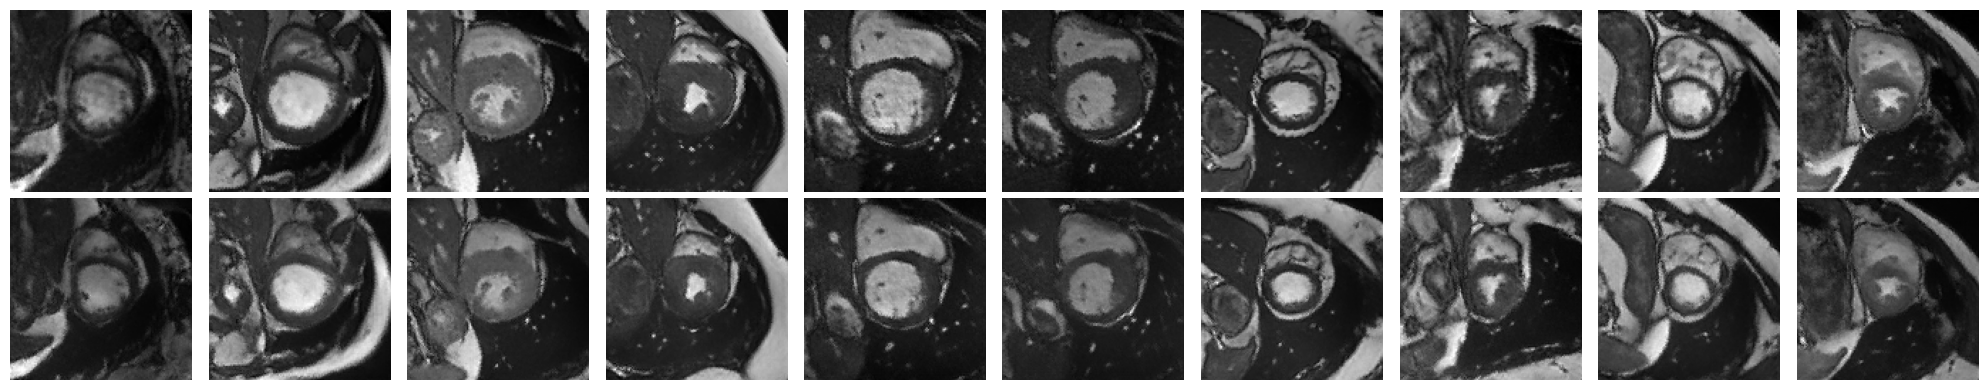

gp1_ED: gp1_ED_17_5
gp1_ES: gp1_ES_13_6
gp2_ED: gp2_ED_13_2
gp2_ES: gp2_ES_15_3
gp3_ED: gp3_ED_15_1
gp3_ES: gp3_ES_15_2
gp4_ED: gp4_ED_11_4
gp4_ES: gp4_ES_15_4
gp5_ED: gp5_ED_14_9
gp5_ES: gp5_ES_16_4


In [25]:
# ==========================================
# 可视化裁剪后的原图与重构图 (10类各取1张)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# 数据根目录
data_root = "/home/yzm/ACDC2/ACDC"
TARGET_SIZE = 112

# 按类别收集图像对 (5个gp × 2个phase = 10类)
image_pairs_by_class = {}

for gp in ['gp1', 'gp2', 'gp3', 'gp4', 'gp5']:
    for phase in ['ED', 'ES']:
        class_name = f"{gp}_{phase}"
        orig_slice_dir = os.path.join(data_root, gp, phase, 'train_image', 'slices')
        label_slice_dir = os.path.join(data_root, gp, phase, 'train_label', 'slices')
        recon_slice_dir = os.path.join(data_root, gp, phase, 'train_image_aug', 'slices')
        
        if os.path.exists(orig_slice_dir) and os.path.exists(recon_slice_dir):
            orig_files = glob.glob(os.path.join(orig_slice_dir, '*.npy'))
            
            pairs_in_class = []
            for orig_path in orig_files:
                filename = os.path.basename(orig_path)
                label_path = os.path.join(label_slice_dir, filename)
                recon_filename = filename.replace('.npy', '_aug.npy')
                recon_path = os.path.join(recon_slice_dir, recon_filename)
                
                if os.path.exists(recon_path) and os.path.exists(label_path):
                    pairs_in_class.append({
                        'orig': orig_path,
                        'label': label_path,
                        'recon': recon_path,
                        'name': filename.replace('.npy', ''),
                        'class': class_name
                    })
            
            if pairs_in_class:
                image_pairs_by_class[class_name] = pairs_in_class

print(f"找到 {len(image_pairs_by_class)} 个类别")


# 从每个类别随机选择1张（不固定种子，每次运行不同）
selected_pairs = []
for class_name in sorted(image_pairs_by_class.keys()):
    pairs = image_pairs_by_class[class_name]
    idx = np.random.randint(0, len(pairs))
    selected_pairs.append(pairs[idx])

num_samples = len(selected_pairs)


# 创建 2行×N列 的图：第一行原图，第二行重构图
fig, axes = plt.subplots(2, num_samples, figsize=(2 * num_samples, 4), dpi=100)

for idx, pair in enumerate(selected_pairs):
    # 加载数据
    orig_img = np.load(pair['orig'])
    label_img = np.load(pair['label'])
    recon_img = np.load(pair['recon'])
    
    # 归一化原图
    orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min() + 1e-8)
    
    # 基于LV质心裁剪原图
    cropped_orig = center_crop_by_lv(orig_img, label_img, TARGET_SIZE)
    
    # 重构图已经是裁剪后的，归一化显示
    recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min() + 1e-8)
    
    # 第一行：原图
    axes[0, idx].imshow(cropped_orig, cmap='gray')
    axes[0, idx].axis('off')
    
    # 第二行：重构图
    axes[1, idx].imshow(recon_img, cmap='gray')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

# 打印文件名
for pair in selected_pairs:
    print(f"{pair['class']}: {pair['name']}")

## other